## 23AIML033 Jugal Lachhwani

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas_datareader import data as pdr
import datetime as dt
from scipy import stats
import yfinance as yf
import time

sns.set_style("whitegrid")

In [5]:
tickers = ['AAPL','MSFT','GOOGL','AMZN']
weights = np.array([0.25,0.25,0.25,0.25])

start = dt.datetime(2020,1,1)
end = dt.datetime.today()

price = pd.DataFrame(index=pd.date_range(start,end)) ## data of start to end in datatfraem

print(price)



Empty DataFrame
Columns: []
Index: [2020-01-01 00:00:00, 2020-01-02 00:00:00, 2020-01-03 00:00:00, 2020-01-04 00:00:00, 2020-01-05 00:00:00, 2020-01-06 00:00:00, 2020-01-07 00:00:00, 2020-01-08 00:00:00, 2020-01-09 00:00:00, 2020-01-10 00:00:00, 2020-01-11 00:00:00, 2020-01-12 00:00:00, 2020-01-13 00:00:00, 2020-01-14 00:00:00, 2020-01-15 00:00:00, 2020-01-16 00:00:00, 2020-01-17 00:00:00, 2020-01-18 00:00:00, 2020-01-19 00:00:00, 2020-01-20 00:00:00, 2020-01-21 00:00:00, 2020-01-22 00:00:00, 2020-01-23 00:00:00, 2020-01-24 00:00:00, 2020-01-25 00:00:00, 2020-01-26 00:00:00, 2020-01-27 00:00:00, 2020-01-28 00:00:00, 2020-01-29 00:00:00, 2020-01-30 00:00:00, 2020-01-31 00:00:00, 2020-02-01 00:00:00, 2020-02-02 00:00:00, 2020-02-03 00:00:00, 2020-02-04 00:00:00, 2020-02-05 00:00:00, 2020-02-06 00:00:00, 2020-02-07 00:00:00, 2020-02-08 00:00:00, 2020-02-09 00:00:00, 2020-02-10 00:00:00, 2020-02-11 00:00:00, 2020-02-12 00:00:00, 2020-02-13 00:00:00, 2020-02-14 00:00:00, 2020-02-15 00:00:00

### Fetching real time data of 4 stocks using stooq

In [6]:
for ticker in tickers:
    print(f"Fetching {ticker}",end = '')
    try:
        print('If y finance is not avlaible then stook')
        df2 = pdr.DataReader(ticker, 'stooq',start,end)
        df2 = df2.sort_index()
        series = df2['Close']

        print('Stooq',end = '')
    except Exception as e:
        # print('If y finance is not avlaible then stook')
        # df2 = pdr.DataReader(ticker, 'stooq',start,end)
        # df2 = df2.sort_index()
        # series = df2['Close']
        df = yf.Ticker(ticker).history(
            start = start.strftime('%Y-%m-%d'),
            end = end.strftime('%Y-%m-%d'),
            auto_adjust=True
            )
        series = df['Close']
        print('Y_finace')
    price[ticker] = series
    time.sleep(1)

# ffill fills the data of upper column
price = price.dropna(how='all').ffill().bfill()
price.head()
print(price.tail())
        
        

Fetching AAPLIf y finance is not avlaible then stook
StooqFetching MSFTIf y finance is not avlaible then stook
StooqFetching GOOGLIf y finance is not avlaible then stook
StooqFetching AMZNIf y finance is not avlaible then stook
Stooq              AAPL    MSFT   GOOGL    AMZN
2025-05-16  211.26  454.27  166.19  205.59
2025-05-19  208.78  458.87  166.54  206.16
2025-05-20  206.86  458.17  163.98  204.07
2025-05-21  202.09  452.57  168.56  201.12
2025-05-22  201.36  454.86  170.87  203.10


In [7]:
price.head()

,AAPL,MSFT,GOOGL,AMZN
2020-01-02,72.7161,153.613,68.1868,94.9005
2020-01-03,72.0115,151.726,67.8302,93.7485
2020-01-06,72.5811,152.118,69.6381,95.1440
2020-01-07,72.2432,150.710,69.5035,95.3430
2020-01-08,73.4042,153.142,69.9983,94.5985


In [8]:
print(price.shape)

(1355, 4)


** Here we got a dataframe price of 1354 days stocks prices of Google,microsoft,amazon and apple **
______________________________________________________________________

### Now calculating the log returns of this stocks 

In [9]:
logR = np.log(price / price.shift(1)).dropna()
logR.head()

,AAPL,MSFT,GOOGL,AMZN
2020-01-03,-0.009737,-0.012360,-0.005243,-0.012213
2020-01-06,0.007879,0.002580,0.026304,0.014776
2020-01-07,-0.004666,-0.009299,-0.001935,0.002089
2020-01-08,0.015943,0.016008,0.007094,-0.007839
2020-01-09,0.021054,0.012240,0.010441,0.004788


### Ploting Histogram

array([[<Axes: title={'center': 'AAPL'}>,
        <Axes: title={'center': 'MSFT'}>],
       [<Axes: title={'center': 'GOOGL'}>,
        <Axes: title={'center': 'AMZN'}>]], dtype=object)

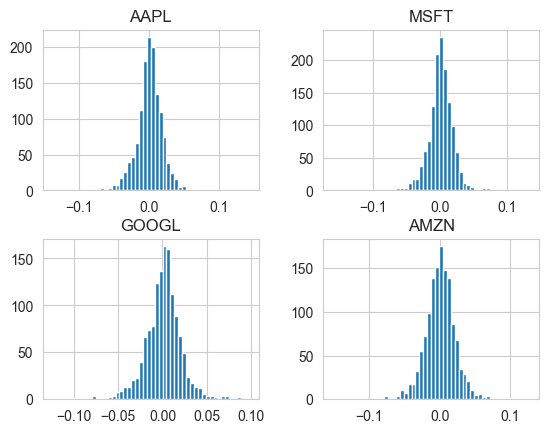

In [10]:
logR.hist(bins = 50)


** The histograms show a little bell shape like curve **

((array([-3.2839615 , -3.02521564, -2.88122989, ...,  2.88122989,
          3.02521564,  3.2839615 ]),
  array([-0.15954898, -0.09959313, -0.08029824, ...,  0.08695706,
          0.09652478,  0.13297171])),
 (np.float64(0.018633652754282817),
  np.float64(0.0008017379813496355),
  np.float64(0.9638562427256435)))

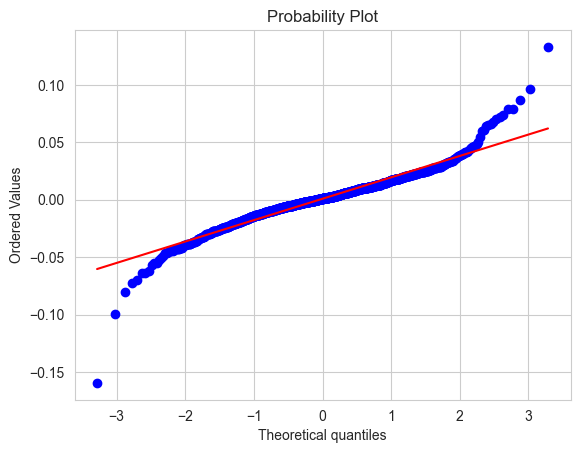

In [11]:
stats.probplot(logR['MSFT'], dist="norm", plot=plt)

** QQ - plot shows that the data is quite normally distributed **

______________________________________________________________________

### Summay
The mean is showing how much we are losing or gaining money.

variance shows how much there are ups and downs in the data.

skewness is showing data has more small losses or gains.

Kurtosis shows how fat are the tails.

In [12]:
summary = pd.DataFrame({
  'Mean':logR.mean(),
  'varience':logR.var(),
  'skewness':logR.skew(),
  'Kurtosis':logR.kurtosis() 
})

In [13]:
summary

,Mean,varience,skewness,Kurtosis
AAPL,0.000752,0.000425,0.020390,6.226807
MSFT,0.000802,0.000372,-0.164616,7.430717
GOOGL,0.000678,0.000431,-0.227661,3.636135
AMZN,0.000562,0.000524,-0.069501,4.160446


Mean (≈0.05–0.08%): On average each stock’s daily return was very small—about a few‐tenths of a percent gain per day.

Variance (≈0.0004): Typical daily swings are around √0.0004 ≃ 2%, so most days see moves of a couple percent.

Skewness (near zero or slightly negative): Returns are roughly symmetric, with a small tendency toward bigger down‐moves than up‐moves.

Kurtosis (>3): All four have “fat tails,” meaning they experience more extreme one‐day jumps or crashes than a normal bell curve would predict.

______________________________________________________________________

### Normal Fit

Now we are finding 95% CI of mean and varience 

In [14]:
mu_norm, sigma_norm = logR.stack().mean(), logR.stack().std(ddof=1)

N = logR.size
z95 = stats.norm.ppf(0.975)
ci_mu_norm = (mu_norm - z95*sigma_norm/np.sqrt(N),
              mu_norm + z95*sigma_norm/np.sqrt(N))

print("Normal fit: Mean ")
print(f"  μ = {mu_norm:.5f}, 95% CI {ci_mu_norm}")

Normal fit: Mean 
  μ = 0.00070, 95% CI (np.float64(0.0001413558101329488), np.float64(0.0012558400131748955))


In [15]:
df = N-1
chi2_low, chi2_high = stats.chi2.ppf([0.025,0.975], df)
ci_sigma_norm = (sigma_norm*np.sqrt(df/chi2_high),
                 sigma_norm*np.sqrt(df/chi2_low))

print("Normal fit: Sigma")
print(f"  σ = {sigma_norm:.5f}, 95% CI {ci_sigma_norm}")

Normal fit: Sigma
  σ = 0.02092, 95% CI (np.float64(0.020536818626581473), np.float64(0.021325210575201474))


Finding mean and sigma with t distribution

In [16]:
returns_stacked = logR.stack().values
df_t,mu_t,sigma_t = stats.t.fit(returns_stacked)

In [17]:
df_t,mu_t,sigma_t

(np.float64(3.6546646101861917),
 np.float64(0.0010493773461387728),
 np.float64(0.014469386072158637))

______________________________________________________________________


## Bootstraping

Taking 1000 estimates by taking random choices of the data so that we can be more confident on our data. 
This step is very important as it outliers cant affect our data and we can be more certain

In [ ]:
B = 1000
estimates = np.array([stats.t.fit(np.random.choice(returns_stacked, size=N, replace=True))
                      for _ in range(B)])

In [ ]:
estimates.shape

The CI is the 2.5 percentile to 97.5 percemntile

In [ ]:
ci_mu_t    = np.percentile(estimates[:,1], [2.5,97.5])
ci_sigma_t = np.percentile(estimates[:,2], [2.5,97.5])

In [ ]:
print("\nStudent’s t fit:")
print(f"  df = {df_t:.1f}, μ = {mu_t:.5f},  σ = {sigma_t:.5f}")
print(f"  95% CI for μ (bootstrap): {ci_mu_t}")
print(f"  95% CI for σ (bootstrap): {ci_sigma_t}")

______________________________________________________________________


### Portfolio Returns
Multiplying the log returns of the stocks with thier weights we get the portfolio returns

In [23]:
portR = logR.dot(weights)

In [24]:
portR.head()

2020-01-03   -0.009888
2020-01-06    0.012885
2020-01-07   -0.003453
2020-01-08    0.007801
2020-01-09    0.012131
dtype: float64

### We will find varience using 3 different methode 
1. Z_score
2. Student t_dist
3. Historical

Using Z_score

In [25]:
M_p = portR.mean()
v_p = portR.std(ddof=1)

In [26]:
### Z-score(0.05)
z05 = stats.norm.ppf(0.05)

In [27]:
#Final var(var norm)
norm_var = M_p + v_p * z05
print(norm_var)

-0.02917699871398255


Using Student t-distribution

In [28]:
t05 = stats.t.ppf(0.05,len(portR) - 1)

In [29]:
var_t = (M_p + sigma_t * t05) * 1

Using Historical Method

In [30]:
hist_var = -np.percentile(portR,5)

In [31]:
hist_var

np.float64(0.02892659425630391)

In [32]:
print("1-Day 95% VaR:")
print(f"  Parametric (Normal):       {norm_var:.5f}")
print(f"  Parametric (Student’s t):  {var_t:.5f}")
print(f"  Historical (5th percentile): {hist_var:.5f}")

1-Day 95% VaR:
  Parametric (Normal):       -0.02918
  Parametric (Student’s t):  -0.02312
  Historical (5th percentile): 0.02893


#### we found that on most days our portfolio wont lost more then 2.9 to 3.1%

#### Hypothesis test

H0: Mean = 0

H1: Mean != 0

In [33]:
t_stat,p_val = stats.ttest_1samp(portR,0,0)

In [34]:
print("t_stat",t_stat,"p_val",p_val)

t_stat 1.4152960186693744 p_val 0.15721184414606912


In [35]:
if p_val < 0.05:
    print("Reject H0 the ,return is significantly different from zero")
else:
    print("Fail to reject H0, no evidence mean return != 0")

Fail to reject H0, no evidence mean return != 0


#### our p-value is greater than 0.05 , hence out return can be just a random noice 

### Correlation and diversification Benifit
We need to observe are the stocks are intercorrelated. If the stocks are correlated the risk increases 

In our portfolio the better option is to pick less correlated stocks to decrease the risk

In [36]:
import seaborn as sns

<Axes: >

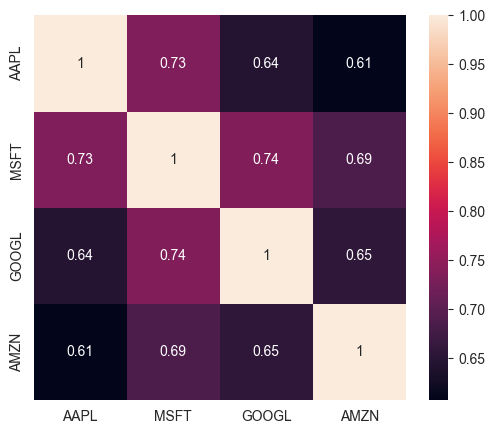

In [37]:
corr = logR.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr,annot=True)

In [38]:
sig_i = logR.std()                         
sig_weighted = np.dot(weights, sig_i)        
sig_portfolio = v_p 

In [39]:
print(f"Weighted avg sigma: {sig_weighted:.4f}")
print(f"Actual portfolio sigma: {sig_portfolio:.4f}")
print(f"Diversification benefit: {sig_weighted-sig_portfolio:.4f}")

Weighted avg sigma: 0.0209
Actual portfolio sigma: 0.0182
Diversification benefit: 0.0027


Here we have decreased the risk by 0.27% 
____________________________________________________________________

## Drawdown
The fall in the portfoloio and the tiem taken yto recover from it 

This study is important to see how downfalls are coming in the market and how much a invester have to wait to recover from it 

The time period of drawdown and recovering from it is the worst phase for a invester


In [40]:
cum_ret = (price / price.iloc[0]).prod(axis = 1)

It compares the prices with the first value and multiplies the columns 

In [41]:
cum_prot = (portR + 1).cumprod()

It keeps track of your total profit/loss by compounding your daily returns — just like reinvesting your earnings every day.

In [42]:
cum_prot

2020-01-03    0.990112
2020-01-06    1.002869
2020-01-07    0.999406
2020-01-08    1.007203
2020-01-09    1.019421
                ...   
2025-05-16    2.074619
2025-05-19    2.076247
2025-05-20    2.057330
2025-05-21    2.045685
2025-05-22    2.058387
Length: 1354, dtype: float64

In [43]:
rolling_max = cum_prot.cummax()
rolling_max

2020-01-03    0.990112
2020-01-06    1.002869
2020-01-07    1.002869
2020-01-08    1.007203
2020-01-09    1.019421
                ...   
2025-05-16    2.380495
2025-05-19    2.380495
2025-05-20    2.380495
2025-05-21    2.380495
2025-05-22    2.380495
Length: 1354, dtype: float64

### It tracks the highest value your portfolio has ever reached up to each day.

In [44]:
drawdown = (cum_prot - rolling_max) / rolling_max

Drawdown tells you how much your portfolio is down from the best it's ever done.

We are measuring the percentage drop relative to the peak.

In [45]:
max_dd = drawdown.min()
end_date = drawdown.idxmin()
start_date = cum_prot[:end_date].idxmax() 
half = cum_prot[end_date:]
finish_date = finish_date = drawdown[end_date:][drawdown[end_date:].values >= 0].index[0].date()
finish_date

datetime.date(2024, 4, 11)

In [46]:
print('max_dd',max_dd,'From',start_date,'To',end_date)

max_dd -0.4397865397638585 From 2021-12-10 00:00:00 To 2023-01-05 00:00:00


Now we are ploting a graph in which we can vizualize every drawdown  

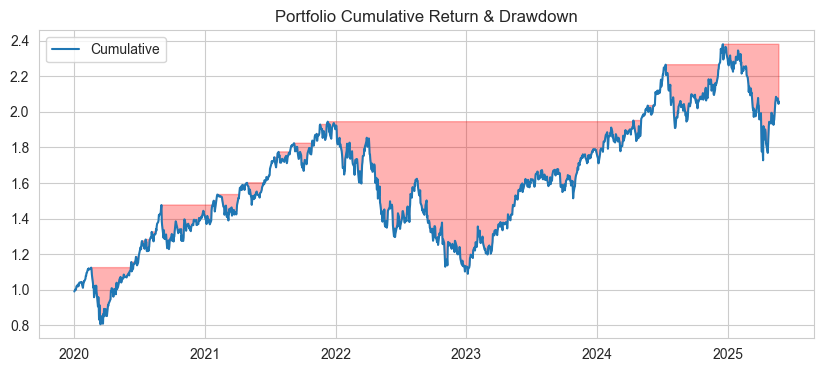

In [47]:
plt.figure(figsize=(10,4))
plt.plot(cum_prot, label='Cumulative')
plt.fill_between(drawdown.index, cum_prot, rolling_max,
                 where=drawdown<0, color='red', alpha=0.3)
plt.title('Portfolio Cumulative Return & Drawdown')
plt.legend()
plt.show()

### Expected Shortfall(ES)

Expected Shortfall(ES) answers If things go really badly (worse than 95% of cases), what’s the average loss in that worst 5%

In [ ]:
# We're calculating Expected Shortfall (ES) in two ways — from historical data and assuming normal distribution.
alpha = 0.5 
ES_historical = portR[portR <= np.percentile(portR, 5)].mean()
ES_norm = (M_p - v_p * stats.norm.pdf(z05) / alpha)

In [49]:
print(f"Historical ES (95%): {ES_historical:.5f}")
print(f"Parametric Normal ES (95%): {ES_norm:.5f}")

Historical ES (95%): -0.04230
Parametric Normal ES (95%): -0.00305


The large difference between our Historical ES and Parametric Normal ES suggests something important about the distribution of your portfolio returns:

Our actual losses are much worse than what the normal distribution predicts.

Your returns are likely not normally distributed.

## VaR Backtesting

How often did the real loss exceed the VaR estimate

In [56]:
var_series= (portR.rolling(1).mean()  + portR.rolling(1).std()*z05)
exc= portR <- norm_var
num_exc= exc.sum()

total =  len(portR)
print(f"Exceptions: {num_exc}/{total} days ({num_exc/total:.2%}, expected ~5%)")

Exceptions: 1302/1354 days (96.16%, expected ~5%)


We're plotting a rolling 60-day historical VaR and comparing it to a static normal VaR.

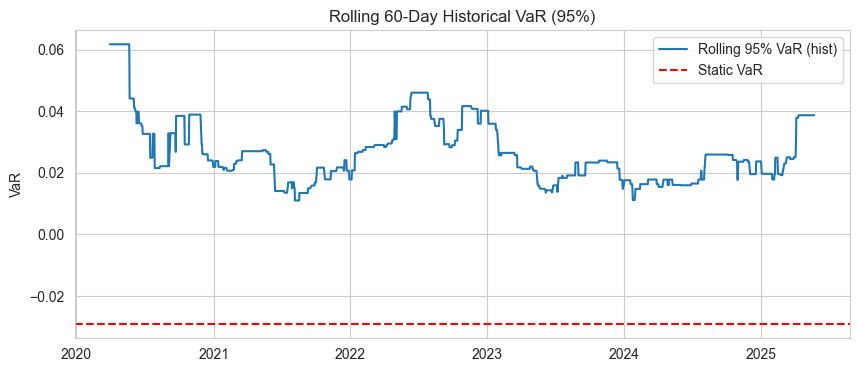

In [51]:
window = 60
roll_var = portR.rolling(window).quantile(0.05).dropna()
plt.figure(figsize=(10,4))
plt.plot(-roll_var, label='Rolling 95% VaR (hist)')
plt.axhline(norm_var, color='red', linestyle='--', label='Static VaR')
plt.title('Rolling 60-Day Historical VaR (95%)')
plt.ylabel('VaR')
plt.legend()
plt.show()

### Jarque-Bera Test for Normality of Portfolio Returns

If p < 0.05:
We reject the null hypothesis of normality.

The Jarque-Bera test is a statistical test of normality. It checks whether your data (like portfolio returns) follow a normal distribution, based on skewness and kurtosis.

In [52]:
jb_stat, jb_p = stats.jarque_bera(portR)
print(f"JB statistic = {jb_stat:.2f}, p-value = {jb_p:.3f}")
if jb_p < 0.05:
    print("Reject normality at 5% level.")
else:
    print("Cannot reject normality.")

JB statistic = 1191.65, p-value = 0.000
Reject normality at 5% level.
